# Mixture Process Models for Continuous-response Tasks | [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AmirHoseinHadian/JEAM/blob/main/docs/notebooks/03_Mixture_Models.ipynb)
[View the notebook on GitHub](https://github.com/AmirHoseinHadian/JEAM/blob/main/docs/notebooks/03_Mixture_Models.ipynb)

Mixture process models are an important class of cognitive models for continuous-response tasks, and they have been widely used in the visual working memory literature. These models assume that observed responses arise from a mixture of distinct cognitive processes, such as memory-based responding and random guessing.

This tutorial demonstrates how to fit **mixture models** within the CRDDM framework. Specifically, we implement a **two-component mixture model** for continuous-report visual working memory tasks, inspired by the seminal work of [Zhang and Luck (2008)](https://doi.org/10.1038/nature06860).

In a typical visual working memory task, participants are asked to memorize the features (e.g., colors) of a set of stimuli. After a brief retention period, they are cued to report the remembered feature of one item by responding on a continuous response scale as below:

![alt text](../imgs/VWM_task.png "Continuous report visual working memory task.")

In this tutorial, we analyze data from Experiment 4 of [Fennel and Ratcliff (2023)](https://doi.org/10.1016/j.cogpsych.2023.101595). The dataset contains behavioral data from six participants performing a visual working memory task with a circular response scale. On each trial, participants were required to memorize either two or four items (i.e., `setSize` $\in \{2, 4\}$), allowing us to examine how memory load influences both response precision and guessing behavior.

---

In [ ]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("jeam") is None:
    subprocess.check_call(
        [sys.executable, 
         "-m", 
         "pip", 
         "install", 
         "--quiet", 
         "git+https://github.com/AmirHoseinHadian/JEAM.git@main"]
    )

## 1. Import required packages

In [1]:
import numpy as np
import seaborn as sns
from tqdm import tqdm

import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import differential_evolution

from jeam.utility.datasets import load_fennell2023
from jeam.Models.Circular import CircularDiffusionModel as CDM

---
## 2. Load the dataset

In [2]:
data = load_fennell2023()

data.head()

,subjectNumber,blockNumber,trialNumber,setSize,rt,responseError
0,1,1,1,4,0.613,-2.443461
1,1,1,2,4,0.723,-0.471239
2,1,1,3,4,0.903,1.396263
3,1,1,4,2,0.734,-0.157080
4,1,1,5,2,0.757,-0.558505


This dataset includes:

- `subjectNumber`: participant identifier,
- `blockNumber`: block index,
- `trialNumber`: trial index,
- `setSize`: number of items to memorize,
- `rt`: response time (seconds),
- `responseError`: angular response error (radians).



## 3. Define a two-component mixture likelihood


Discrete theories of visual working memory (e.g., [Zhang and Luck, 2008](https://doi.org/10.1038/nature06860)) propose that working memory consists of a limited number of discrete “**slots**.” Under this view, an item is either successfully stored in working memory or not, and responses reflect a mixture of memory-based reports and random guesses.

[Zhang and Luck (2008)](https://doi.org/10.1038/nature06860) formalized this idea in a hybrid discrete model, in which the **precision of memory** representations decreases with increasing set size up to the capacity limit. In the diffusion modeling framework, this reduction in precision can be captured by allowing the **drift magnitude** of the diffusion process to vary across set sizes. Once the capacity limit is exceeded, additional items are assumed not to be stored in working memory; responses to these items are therefore attributed to **guessing**, while the precision of stored items remains constant.

![alt text](../_figures/two_comp_mixture.png "Two-component mixture model")

Within our mixture modeling approach, this theory motivates a process in which guessing occurs primarily when the number of presented stimuli exceeds working memory capacity (typically assumed to be around three items). Accordingly, for trials with `setSize=2`, the probability of guessing is fixed to zero.

In the context of our mixture modeling approach, this theory motivates a process in which guessing occurs primarily when the number of presented stimuli exceeds working memory capacity (typically assumed to be around three items). Consequently, the probability of guessing is set to zero to .

The model therefore assumes that, on each trial with `setSize=4`:

- with probability `1 − p_guess`, responses are generated by a circular diffusion process reflecting memory-based responding;
- with probability `p_guess`, responses are generated by a zero-drift process represeing the guessing process.

and on each trial with `setSize=2`:

- Responses are generated by a circular diffusion process reflecting memory-based responding and there is no guessing component.

Both the **drift magnitude** of the diffusion component and the **guessing probability** are allowed to depend on memory set size, enabling the model to capture systematic effects of memory load on both response precision and guessing behavior.

In [3]:
def negative_log_likelihood(params, rt, theta, setSize, model):
    threshold =  params[0] 
    ndt = params[1]
    drift_angle = params[2]
    
    drift_direction = np.array([np.cos(drift_angle), 
                                np.sin(drift_angle)])
    
    # Drift magnitudes by set size
    drift_magnitudes = np.empty(setSize.shape)
    drift_magnitudes[setSize == 2] = params[3]
    drift_magnitudes[setSize == 4] = params[4]
    
    # Trial-wise drift vectors
    drift_vectors = np.outer(drift_magnitudes, drift_direction)
    
    # Weights of geussing process by set size
    p_guess = np.empty(setSize.shape)
    p_guess[setSize==2] = 0 
    p_guess[setSize==4] = params[5]    
    
    non_guesing_pdf = np.exp(model.joint_lpdf(rt, theta, drift_vectors, ndt, threshold))
    gussing_pdf = np.exp(model.joint_lpdf(rt, theta, np.zeros((2,)), ndt, threshold))
    
    mixture_pdf = (1 - p_guess) * non_guesing_pdf + p_guess * gussing_pdf
    logpdf = np.log(mixture_pdf)
    
    return -np.sum(logpdf)

---

## 4. Estimate parameters for each participant

In [4]:
param_names = ['threshold', 
               'ndt', 
               'drift_angle',
               'drift_magnitude2',
               'drift_magnitude4',
               'p_guess',
              ]


# Parameter bounds
bounds = [
    (0.05, 5.0),   # threshold
    (0.0, 1.0),    # non-decision time
    (-np.pi, np.pi),    # drift angle
    (0, 8.0),   # drift magnidute (length) for setSize=2
    (0, 8.0),   # drift magnidute (length) for setSize=4
    (0.0, 1.0), # p_guess for setSize=4
]

In [5]:
model = CDM(threshold_dynamic='fixed')
estimation_rows = []

# Estimate model parameters separately for each participant
for sbj in tqdm(data.subjectNumber.unique()):
    sbj_data = data[data['subjectNumber']==sbj].reset_index(drop=True)
    
    # Optimize the negative log-likelihood function
    result = differential_evolution(
                negative_log_likelihood,
                bounds=bounds,
                args=(sbj_data["rt"].values, 
                      sbj_data["responseError"].values, 
                      sbj_data["setSize"].values, model),
    )
    
    k = len(result.x) # number of free parameters
    n = sbj_data.shape[0] # number of trials for the participant
    nlpdf = result.fun # optimized negative log-likelihood value
    
    # store the goodness of fit criterion and estimated parameters for each subject
    row = {
        "subjectNumber": sbj, 
        "nlpdf": nlpdf, 
        "AIC": 2 * nlpdf + 2 * k, 
        "BIC": 2 * nlpdf + k * np.log(n)
    }
    row.update(dict(zip(param_names, result.x)))
    
    estimation_rows.append(row)

100%|█████████████████████████████████████████████| 6/6 [00:56<00:00,  9.39s/it]


In [6]:
estimation_data = pd.DataFrame(estimation_rows)
estimation_data

,subjectNumber,nlpdf,AIC,BIC,threshold,ndt,drift_angle,drift_magnitude2,drift_magnitude4,p_guess
0,1,2480.703229,4973.406458,5008.963907,1.341294,0.282662,0.023035,2.826787,2.443354,0.304788
1,2,3677.453203,7366.906407,7403.919026,1.426471,0.377655,0.068479,2.630579,2.403024,0.309157
2,3,1540.843462,3093.686925,3131.127652,1.858441,0.181595,-0.018826,3.653876,3.100707,0.096401
3,4,4320.694883,8653.389765,8690.449802,1.770016,0.409628,0.001823,2.580465,2.159012,0.268208
4,5,3963.776461,7939.552922,7976.961904,1.375988,0.132265,0.008258,2.449471,2.404431,0.288599
5,6,4376.829255,8765.658510,8803.046767,1.596289,0.153365,0.003437,2.348480,2.144724,0.250312


---

## 5. Model-based prediction (posterior predictive simulation)

We next perform **posterior predictive simulations** using the fitted parameters.
By comparing summary statistics from the observed data and model-generated data,
we assess whether the model captures systematic effects of task instructions
and stimulus difficulty.

In [7]:
n_sample = 500
simulated = []

for sbj in data.subjectNumber.unique():
    prms = estimation_data[estimation_data.subjectNumber == sbj].iloc[0]

    drift_dir = np.array([
        np.cos(prms["drift_angle"]),
        np.sin(prms["drift_angle"]),
    ])

    for setSize in [2, 4]:
        drift_vec = prms[f"drift_magnitude{setSize}"] * drift_dir
        
        if setSize == 2:
            p_guess = 0
        else:
            p_guess = prms["p_guess"]

        non_guess = model.simulate(
            drift_vec,
            prms["ndt"],
            threshold=prms["threshold"],
            n_sample=n_sample - int(p_guess * n_sample),
        )

        guess = model.simulate(
            np.zeros((2,)),
            prms["ndt"],
            threshold=prms["threshold"],
            n_sample=int(p_guess * n_sample),
        )

        df = pd.concat([non_guess, guess])
        df["setSize"] = setSize
        df["subjectNumber"] = sbj

        simulated.append(df)

model_prediction = pd.concat(simulated, ignore_index=True)
model_prediction.head()

,rt,response,setSize,subjectNumber
0,0.806662,0.248512,2,1
1,0.454662,-0.521698,2,1
2,0.737662,-0.737372,2,1
3,0.706662,0.129741,2,1
4,0.578662,-1.053031,2,1


## 6. Compare summary measures

A common approach is to compare mean RT and mean absolute deviation across set size:

In [8]:
data_plot = data.copy()
data_plot["abs_dev"] = np.abs(data['responseError'])

pred_plot = model_prediction.copy()
pred_plot["abs_dev"] = np.abs(pred_plot['response'])

In [9]:
# Helper: compute mean + SEM
def summarize(df, value_col, source_name):
    g = (
        df.groupby(["setSize"])[value_col]
        .agg(mean="mean", sem="sem")
        .reset_index()
    )
    g["source"] = source_name
    g["metric"] = value_col
    return g

In [10]:
def plot_metric(ax, metric, ylabel):
    sub = summary[summary["metric"] == metric].copy()

    # plot each source as a separate line with error bars
    for (source, ), sdf in sub.groupby(["source"]):
        sdf = sdf.sort_values("setSize")
        ax.errorbar(
            sdf["setSize"],
            sdf["mean"],
            yerr=sdf["sem"],
            marker="o",
            linewidth=2,
            linestyle="-" if source == "Data" else "--",
            label=f"{source}",
            capsize=3,
        )

    ax.set_xlabel("Set size")
    ax.set_ylabel(ylabel)
    ax.legend(frameon=False)
    ax.set_xticks([2, 4], [2, 4])

In [11]:
summary = pd.concat(
    [
        summarize(data_plot.groupby(['subjectNumber', 'setSize']).mean(), 
                  "rt", "Data"),
        summarize(data_plot.groupby(['subjectNumber', 'setSize']).mean(), "abs_dev", "Data"),
        summarize(pred_plot.groupby(['subjectNumber', 'setSize']).mean(), "rt", "Prediction"),
        summarize(pred_plot.groupby(['subjectNumber', 'setSize']).mean(), "abs_dev", "Prediction"),
    ],
    ignore_index=True,
)

summary["setSize"] = summary["setSize"].astype(int)

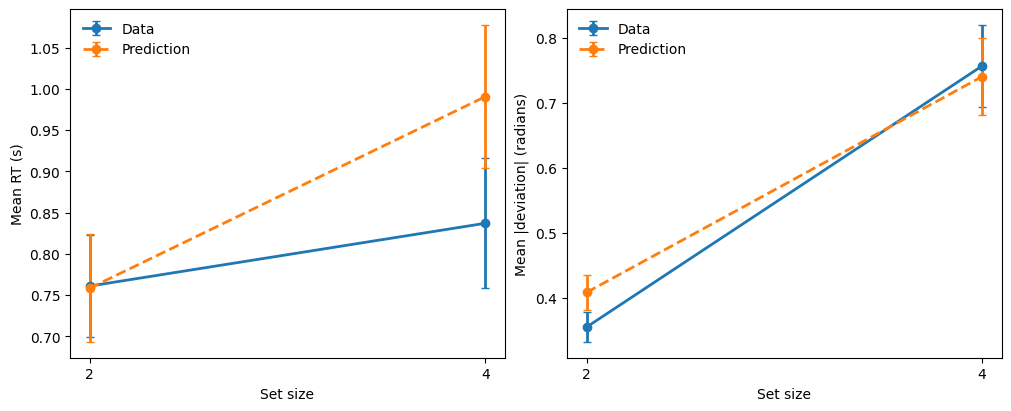

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

plot_metric(axes[0], "rt", "Mean RT (s)")
plot_metric(axes[1], "abs_dev", "Mean |deviation| (radians)")

plt.show()

---

## Notes

- Mixture models can also be used to account for **multimodal response-error distributions**, as observed in continuous-report tasks (e.g., [Bays et al, 2009](https://doi.org/10.1167/9.10.7)).

- CRDDM supports straightforward implementation of mixture models with **more than two components**, and this framework generalizes naturally to richer mixture structures and alternative cognitive process assumptions.

---

## References

- Bays, P. M., Catalao, R. F., & Husain, M. (2009). The precision of visual working memory is set by allocation of a shared resource. *Journal of Vision*, 9(10), 7-7. [https://doi.org/10.1167/9.10.7](https://doi.org/10.1167/9.10.7)

- Fennell, A., & Ratcliff, R. (2023). A spatially continuous diffusion model of visual working memory. *Cognitive Psychology*, 145, 101595. [https://doi.org/10.1016/j.cogpsych.2023.101595](https://doi.org/10.1016/j.cogpsych.2023.101595)

- Zhang, W., & Luck, S. J. (2008). Discrete fixed-resolution representations in visual working memory. *Nature*, 453(7192), 233-235. [https://doi.org/10.1038/nature06860](https://doi.org/10.1038/nature06860)